# 챔프 태그로 승패 예측

### Imports

In [ ]:
import pandas as pd
import json
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
import os

# matplotlib 한글 폰트 설정
if os.name == 'nt':
    plt.rc('font', family='Malgun Gothic')
elif os.name == 'posix':
    plt.rc('font', family='AppleGothic')
else:
    plt.rc('font', family='NanumGothic')
plt.rc('axes', unicode_minus=False)

## Read Data

In [ ]:
# read dataset
df = pd.read_csv('WinPredDataset.csv')
df = df.drop(columns=['Unnamed: 0'])
df = df.iloc[:-1].astype('float32')

# target : 'win'
# split dataset
X = df.drop(columns=['win'])
y = df['win']

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## Logistic Regression Model

In [ ]:
# sklearn, logistic regression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# logistic regression
logistic = LogisticRegression()
logistic.fit(X_train, y_train)
y_pred = logistic.predict(X_test)
print('Logistic Regression')
print('Accuracy:', accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

Logistic Regression
Accuracy: 0.5187831682754586
[[6069 5954]
 [5562 6346]]
              precision    recall  f1-score   support

         0.0       0.52      0.50      0.51     12023
         1.0       0.52      0.53      0.52     11908

    accuracy                           0.52     23931
   macro avg       0.52      0.52      0.52     23931
weighted avg       0.52      0.52      0.52     23931



In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119655 entries, 0 to 119654
Data columns (total 43 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   me_전사      119655 non-null  float32
 1   en_전사      119655 non-null  float32
 2   me_암살자     119655 non-null  float32
 3   en_암살자     119655 non-null  float32
 4   me_마법사     119655 non-null  float32
 5   en_마법사     119655 non-null  float32
 6   me_원거리 공격  119655 non-null  float32
 7   en_원거리 공격  119655 non-null  float32
 8   me_지원가     119655 non-null  float32
 9   en_지원가     119655 non-null  float32
 10  me_탱커      119655 non-null  float32
 11  en_탱커      119655 non-null  float32
 12  me_AP      119655 non-null  float32
 13  en_AP      119655 non-null  float32
 14  me_AD      119655 non-null  float32
 15  en_AD      119655 non-null  float32
 16  me_CC      119655 non-null  float32
 17  en_CC      119655 non-null  float32
 18  me_유틸      119655 non-null  float32
 19  en_유틸      119655 non-n

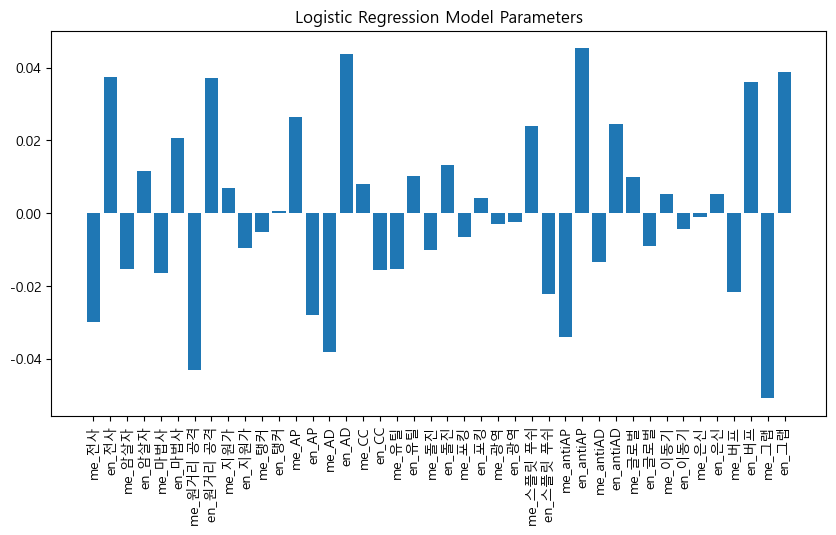

In [ ]:
# visualized Model parameter ananlysis
# weight
plt.figure(figsize=(10, 5))
plt.bar(X.columns, logistic.coef_[0])
plt.xticks(rotation=90)
plt.title('Logistic Regression Model Parameters')
plt.show()

In [ ]:
# Random Forest
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier()
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)
print('Random Forest')
print('Accuracy:', accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

Random Forest
Accuracy: 0.5140612594542644
[[6434 5589]
 [6040 5868]]
              precision    recall  f1-score   support

         0.0       0.52      0.54      0.53     12023
         1.0       0.51      0.49      0.50     11908

    accuracy                           0.51     23931
   macro avg       0.51      0.51      0.51     23931
weighted avg       0.51      0.51      0.51     23931



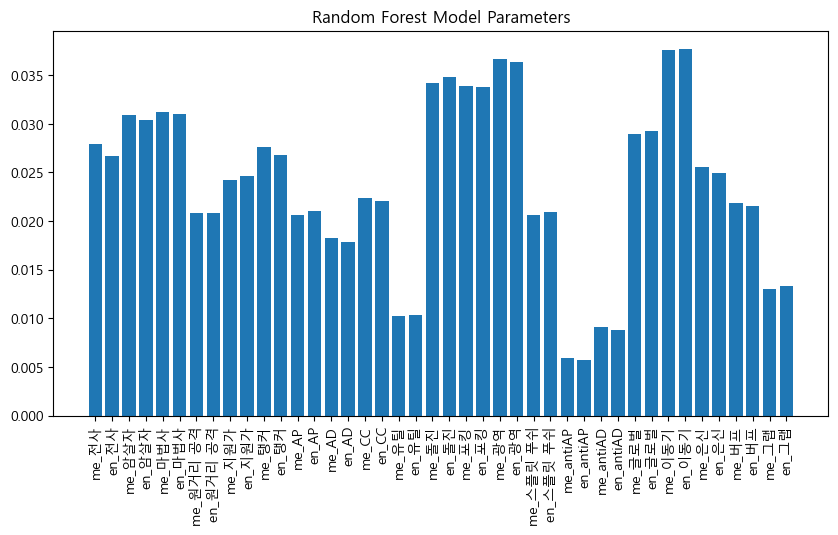

In [ ]:
# visualized Model parameter ananlysis
# weight
plt.figure(figsize=(10, 5))
plt.bar(X.columns, rf.feature_importances_)
plt.xticks(rotation=90)
plt.title('Random Forest Model Parameters')
plt.show()

## MLP with pyTorch

In [ ]:
# torch for MLP
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import random_split
from torch.utils.data import DataLoader, TensorDataset

import torch.nn.functional as F

### Model

In [ ]:
# cuda 자동선택
device = 'cuda' if torch.cuda.is_available() else 'cpu'
#device = 'cpu'

In [ ]:
# layer1: 100, layer2: 50, layer3: 1
# activation function: linear, linear, sigmoid
# optimizer: Adam
# loss function: BCELoss
# epoch: 1000
# batch size: 10000
class MLP(nn.Module):
    def __init__(self, input_size):
        super(MLP, self).__init__()
        self.fc1 = nn.Linear(input_size, 100)
        self.dropout1 = nn.Dropout(0.4)
        self.fc2 = nn.Linear(100, 50)
        self.dropout2 = nn.Dropout(0.4)
        self.fc3 = nn.Linear(50, 1)
    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = self.dropout1(x)
        x = F.relu(self.fc2(x))
        x = self.dropout2(x)
        x = F.sigmoid(self.fc3(x))
        return x

In [ ]:
# train, test dataset


# torch data
X_train_tensor = torch.tensor(X_train.values, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32)

X_test_tensor = torch.tensor(X_test.values, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32)

# dataset
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

# dataloader
train_loader = DataLoader(train_dataset, batch_size=100, shuffle=True)

In [ ]:
# dataloader
train_loader = DataLoader(train_dataset, batch_size=10000, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=10000, shuffle=False)

In [ ]:
# model, optimizer, loss function
model = MLP(input_size=X_train.shape[1]).to(device)
optimizer = optim.Adam(model.parameters())
criterion = nn.BCELoss()

In [ ]:
# train

model.train()
pBar = tqdm(range(1000))
for epoch in pBar:
    pBar.set_description(f'Epoch {epoch+1}')
    pBar.update(1)
    pBar.refresh()

    for x, y in train_loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        y_pred = model(x)
        loss = criterion(y_pred, y.view(-1, 1))
        loss.backward()
        optimizer.step()

    with torch.no_grad():
        for val_x, val_y in test_loader:
            val_x, val_y = val_x.to(device), val_y.to(device)
            val_y_pred = model(val_x)
            val_loss = criterion(val_y_pred, val_y.view(-1, 1))
    
    pBar.set_postfix({'Loss': loss.item(), 'train_acc': accuracy_score(y_train, model(X_train_tensor.to(device)).cpu().detach().numpy() > 0.5), \
                      'Val Loss': val_loss.item(), 'val_acc': accuracy_score(y_test, model(X_test_tensor.to(device)).cpu().detach().numpy() > 0.5)})
    #pBar.set_postfix({'Accuracy': accuracy_score(y_train, model(X_train_tensor.to(device)).cpu().detach().numpy() > 0.5)})

    # test


  0%|          | 0/1000 [00:00<?, ?it/s]

In [ ]:
# test
model.eval()
y_true = []
y_pred = []
for x, y in test_loader:
    x, y = x.to(device), y.to(device)
    y_true.extend(y.tolist())
    y_pred.extend(model(x).tolist())


y_pred = [1 if i[0] > 0.5 else 0 for i in y_pred]

print('MLP')
print('Accuracy:', accuracy_score(y_true, y_pred))
print(confusion_matrix(y_true, y_pred))
print(classification_report(y_true, y_pred))

MLP
Accuracy: 0.5105511679411642
[[5948 6075]
 [5638 6270]]
              precision    recall  f1-score   support

         0.0       0.51      0.49      0.50     12023
         1.0       0.51      0.53      0.52     11908

    accuracy                           0.51     23931
   macro avg       0.51      0.51      0.51     23931
weighted avg       0.51      0.51      0.51     23931



# Version 2

### Imports

In [1]:
import pandas as pd
import json
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
import os

# matplotlib 한글 폰트 설정
if os.name == 'nt':
    plt.rc('font', family='Malgun Gothic')
elif os.name == 'posix':
    plt.rc('font', family='AppleGothic')
else:
    plt.rc('font', family='NanumGothic')
plt.rc('axes', unicode_minus=False)

## Read Data

In [2]:
# read dataset
df = pd.read_csv('WinPredDataset_v2.csv')
df = df.iloc[:-1].astype('float32')

# target : 'win'
# split dataset
X = df.drop(columns=['win'])
y = df['win']

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## Logistic Regression Model

In [3]:
# sklearn, logistic regression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# logistic regression
logistic = LogisticRegression()
logistic.fit(X_train, y_train)
y_pred = logistic.predict(X_test)
print('Logistic Regression')
print('Accuracy:', accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

Logistic Regression
Accuracy: 0.528220414530867
[[ 4668 12417]
 [ 4518 14293]]
              precision    recall  f1-score   support

         0.0       0.51      0.27      0.36     17085
         1.0       0.54      0.76      0.63     18811

    accuracy                           0.53     35896
   macro avg       0.52      0.52      0.49     35896
weighted avg       0.52      0.53      0.50     35896



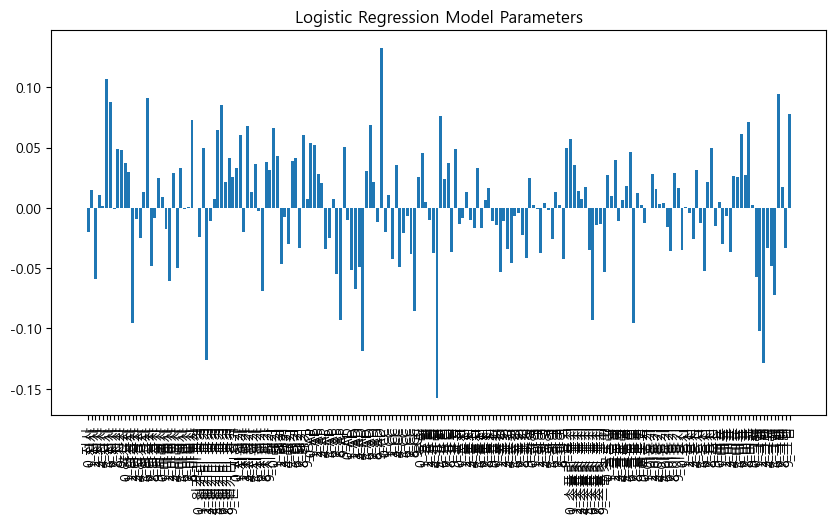

In [5]:
# visualized Model parameter ananlysis
# weight
plt.figure(figsize=(10, 5))
plt.bar(X.columns, logistic.coef_[0])
plt.xticks(rotation=90)
plt.title('Logistic Regression Model Parameters')
plt.show()

In [6]:
# Random Forest
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier()
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)
print('Random Forest')
print('Accuracy:', accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

Random Forest
Accuracy: 0.980777802540673
[[16677   408]
 [  282 18529]]
              precision    recall  f1-score   support

         0.0       0.98      0.98      0.98     17085
         1.0       0.98      0.99      0.98     18811

    accuracy                           0.98     35896
   macro avg       0.98      0.98      0.98     35896
weighted avg       0.98      0.98      0.98     35896



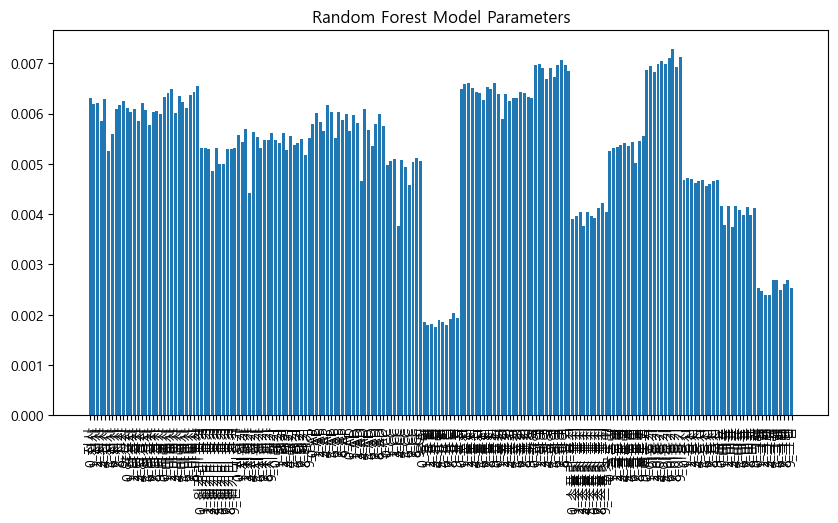

In [7]:
# visualized Model parameter ananlysis
# weight
plt.figure(figsize=(10, 5))
plt.bar(X.columns, rf.feature_importances_)
plt.xticks(rotation=90)
plt.title('Random Forest Model Parameters')
plt.show()

In [16]:
# 중요도가 낮은 feature 확인
print('Random Forest')
print('Feature Importance')
for idx, val in enumerate(rf.feature_importances_):
    if val < 0.01:
        print(X.columns[idx], val)

Random Forest
Feature Importance
0_전사 0.006311259712686068
1_전사 0.006190883931863677
2_전사 0.006213484156066603
3_전사 0.005848429078128299
4_전사 0.006282906854864992
5_전사 0.005253487928552926
6_전사 0.005595321073298515
7_전사 0.006099753884285265
8_전사 0.006165468332153795
9_전사 0.006239668750360917
0_암살자 0.006113740782219239
1_암살자 0.006028195911883643
2_암살자 0.006096447909874541
3_암살자 0.005846165948702937
4_암살자 0.006212320825219861
5_암살자 0.006068120545140383
6_암살자 0.005774765065018891
7_암살자 0.00603436313335339
8_암살자 0.006058852683414809
9_암살자 0.005995410634327248
0_마법사 0.0063223942922697104
1_마법사 0.0064139298644642915
2_마법사 0.006483243168446262
3_마법사 0.006008163517072359
4_마법사 0.006340360813411705
5_마법사 0.006230048416932148
6_마법사 0.006101645046520635
7_마법사 0.006374333901344472
8_마법사 0.006432926319488521
9_마법사 0.006544913381958236
0_원거리 공격 0.005320988872100251
1_원거리 공격 0.005316915609311373
2_원거리 공격 0.005302801404397984
3_원거리 공격 0.004862275297675486
4_원거리 공격 0.005310877586553861
5_원거리 공격 0.00498

## MLP with pyTorch

In [8]:
# torch for MLP
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import random_split
from torch.utils.data import DataLoader, TensorDataset

import torch.nn.functional as F

### Model

In [9]:
# cuda 자동선택
device = 'cuda' if torch.cuda.is_available() else 'cpu'
#device = 'cpu'

In [10]:
# layer1: 100, layer2: 50, layer3: 1
# activation function: linear, linear, sigmoid
# optimizer: Adam
# loss function: BCELoss
# epoch: 1000
# batch size: 10000
class MLP(nn.Module):
    def __init__(self, input_size):
        super(MLP, self).__init__()
        self.fc1 = nn.Linear(input_size, 200)
        self.dropout1 = nn.Dropout(0.4)
        self.fc2 = nn.Linear(200, 100)
        self.dropout2 = nn.Dropout(0.4)
        self.fc3 = nn.Linear(100, 1)
    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = self.dropout1(x)
        x = F.relu(self.fc2(x))
        x = self.dropout2(x)
        x = F.sigmoid(self.fc3(x))
        return x

In [ ]:
# train, test dataset


# torch data
X_train_tensor = torch.tensor(X_train.values, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32)

X_test_tensor = torch.tensor(X_test.values, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32)

# dataset
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

# dataloader
train_loader = DataLoader(train_dataset, batch_size=10000, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=10000, shuffle=False)

In [13]:
# model, optimizer, loss function
model = MLP(input_size=X_train.shape[1]).to(device)
optimizer = optim.Adam(model.parameters())
criterion = nn.BCELoss()

In [14]:
# train

model.train()
pBar = tqdm(range(1000))
for epoch in pBar:
    pBar.set_description(f'Epoch {epoch+1}')
    pBar.update(1)
    pBar.refresh()

    for x, y in train_loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        y_pred = model(x)
        loss = criterion(y_pred, y.view(-1, 1))
        loss.backward()
        optimizer.step()

# validation
    with torch.no_grad():
        for val_x, val_y in test_loader:
            val_x, val_y = val_x.to(device), val_y.to(device)
            val_y_pred = model(val_x)
            val_loss = criterion(val_y_pred, val_y.view(-1, 1))
    
    pBar.set_postfix({'Loss': loss.item(), 'train_acc': accuracy_score(y_train, model(X_train_tensor.to(device)).cpu().detach().numpy() > 0.5), \
                      'Val Loss': val_loss.item(), 'val_acc': accuracy_score(y_test, model(X_test_tensor.to(device)).cpu().detach().numpy() > 0.5)})
    #pBar.set_postfix({'Accuracy': accuracy_score(y_train, model(X_train_tensor.to(device)).cpu().detach().numpy() > 0.5)})
    

  0%|          | 0/1000 [00:00<?, ?it/s]

In [15]:
# test
model.eval()
y_true = []
y_pred = []
with torch.no_grad():
    for x, y in test_loader:
        x, y = x.to(device), y.to(device)
        y_true.extend(y.tolist())
        y_pred.extend(model(x).tolist())

y_pred = [1 if i[0] > 0.5 else 0 for i in y_pred]

print('MLP')
print('Accuracy:', accuracy_score(y_true, y_pred))
print(confusion_matrix(y_true, y_pred))
print(classification_report(y_true, y_pred))

MLP
Accuracy: 0.9179574325830177
[[15403  1682]
 [ 1263 17548]]
              precision    recall  f1-score   support

         0.0       0.92      0.90      0.91     17085
         1.0       0.91      0.93      0.92     18811

    accuracy                           0.92     35896
   macro avg       0.92      0.92      0.92     35896
weighted avg       0.92      0.92      0.92     35896

